# ipynb/rgcnformer_cls_res_nofont_backup.ipynb - RGCNFormer 分类结果(无字体,备份) / RGCNFormer classification (no font, backup)

## 项目背景 / Background
RGCNFormer 分类结果(无字体,备份)
RGCNFormer classification (no font, backup)

## 功能模块 / Modules
- 备份版分类结果展示
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/rgcnformer_cls_res_nofont.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



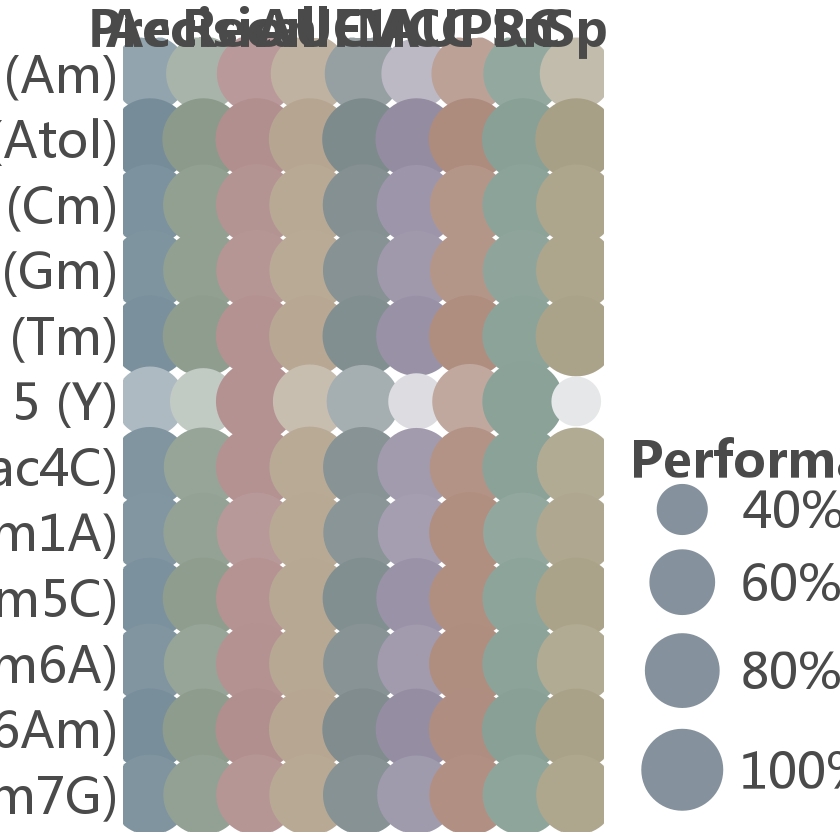

In [4]:
# 1. 安装并加载字体管理包
# if(!require(showtext)) install.packages("showtext")
library(showtext)

# --- 以下是你原本的代码，只需修改 theme 中的 family 参数 ---

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(scales)
df <- read.csv("data/res.csv")

metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
class_levels <- unique(df$Class)

plot_data <- df %>%
  select(Class, all_of(metric_levels)) %>%
  pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value")

plot_data$Metric <- factor(plot_data$Metric, levels = metric_levels)
plot_data$Class <- factor(plot_data$Class, levels = rev(class_levels))
# 计算各 Metric 的平均值 (Total 栏)
metric_avg <- plot_data %>%
  group_by(Metric) %>%
  summarise(Avg_Value = mean(Value, na.rm = TRUE)) %>%
  mutate(Group = "Total")

# 2. 定义配色
bg_colors <- c("#ffffff") 
bubble_palette <- c("#EAECEE", "#ABB2B9", "#85929E", "#5D6D7E", "#34495E")
total_palette <- c("#A9DFBF", "#7DCEA0")
# 3. 创建背景层数据
bg_data <- data.frame(
  Metric = factor(metric_levels, levels = metric_levels),
  xmin = seq_along(metric_levels) - 0.5,
  xmax = seq_along(metric_levels) + 0.5,
  bg_fill = rep(bg_colors, length.out = length(metric_levels))
)


# 2. 注册微软雅黑 (确保名称与系统识别的一致)
# 如果你安装的是 .ttc，通常名字就是 "Microsoft YaHei"
font_add("YaHei", 
         regular = "/usr/share/fonts/truetype/myfonts/msyh.ttf", 
         bold = "/usr/share/fonts/truetype/myfonts/msyhbd.ttf")

# 2. 开启自动渲染
showtext_auto()

# 3. 这里的 dpi 建议与 ggsave 保持一致，防止预览和保存效果不一
showtext_opts(dpi = 300)



# 1. 定义 9 种莫兰迪色相
morandi_hues <- c(
  "Acc" = "#768D99", "Precision" = "#8A9A8A", "Recall" = "#B28F8F",
  "AUC" = "#B6A691", "F1" = "#7E8B8C", "MCC" = "#938BA1",
  "AUPRC" = "#AD8B7D", "Sn" = "#88A096", "Sp" = "#A8A085"
)

# 2. 数据准备
metric_levels <- c("Acc","Precision","Recall", "AUC" ,  "F1","MCC", "AUPRC","Sn","Sp")
class_levels <- unique(df$Class)

plot_data <- df %>%
  select(Class, all_of(metric_levels)) %>%
  pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Class = factor(Class, levels = rev(class_levels))
  ) %>%
  group_by(Metric) %>%
  mutate(
    point_color = col_numeric(
      palette = c("#EAECEE", morandi_hues[as.character(Metric[1])]), 
      domain = c(0.35, 1) 
    )(Value),
    text_color = "#4A4A4A" # 统一使用深灰字，也可根据上一版逻辑改回动态色
  ) %>%
  ungroup()

# 【删除了metric_avg汇总数据的计算，因为不需要Total栏了】

# 3. 绘制主图 (p1)
p1 <- ggplot() +
  geom_rect(data = bg_data, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = bg_fill), 
            alpha = 1, show.legend = FALSE) +
  scale_fill_identity() + 
  
  # 绘制圆圈
  geom_point(data = plot_data, aes(x = Metric, y = Class, size = Value, color = point_color)) +
  
  # geom_text(data = plot_data, aes(x = Metric, y = Class, 
  #                                label = sprintf("%.2f", Value * 100),
  #                                color = text_color), 
  #           size = 4, fontface = "bold", family = "YaHei", show.legend = FALSE) +
  
  scale_color_identity() + 
  
  # --- 核心修改：配置尺寸图例 ---
  scale_size_continuous(
    name = "Performance Value",
    range = c(10, 22),       # 最小值设为10，确保38.80%也能包住文字
    limits = c(0.35, 1), 
    breaks = c(0.4, 0.6, 0.8, 1.0),
    labels = c("40%", "60%", "80%", "100%")
  ) +
  
  # 强制给图例上色（使用莫兰迪中性色）
  guides(
    size = guide_legend(
      override.aes = list(color = "#85929E"), # 使用中性莫兰迪灰
      order = 1
    )
  ) +
  
  scale_x_discrete(position = "top", expand = expansion(mult = c(0, 0))) + 
  scale_y_discrete(expand = expansion(mult = c(0.05, 0.05))) +
  theme_minimal() +
  theme(
    # 修改：全局字体指定为 YaHei
    text = element_text(family = "YaHei"),
    axis.text.x = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 12, color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = 12, color = "#4A4A4A")
  )

# 【直接删除了p2汇总栏的全部绘制代码】

# 5. 最终图表（无需合并，直接使用p1，保留图例配置）
final_plot <- p1 & 
  theme(legend.justification = "bottom") # 让图例对齐上方

# 保存（可根据需要微调宽高，因为移除了汇总栏，高度可适当减小）
ggsave("png2/rgcnformer_cls_res_nofont.pdf", final_plot, width = 12, height = 10, dpi = 300)
print(final_plot)

Loading required package: sysfonts

Loading required package: showtextdb


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


